# Silhouette and saved endpoint checks

Read saved results, inspect the numbers, draw figures, and export a new snapshot.
This notebook runs independently of the other notebooks.
`OWNED_TABLES` below lists the CSVs exported here; figure names appear in
the drawing cells.

**Inputs:** saved silhouette tables and original feature/label arrays for every run. No training runs here. Additional computation is opt-in in the final analysis chapter.
**Use:** run from the top once. For presentation edits, rerun only that chapter's
display-settings and drawing cells. For changes to inputs or display targets,
restart the kernel and run all cells so that every chapter uses the same conditions.
Save the notebook file before exporting to include your code in the source copy.

## 1. Settings

Shared defaults are in `figure_settings.py`; the next cell reloads them.
`DISPLAY_TARGETS=None` selects the lowest seed-median final classifier validation
loss for each model. Ties within absolute 1e-6 (relative tolerance zero) choose
the smaller target. A model dictionary changes the display only; HP eta selection
remains unchanged. PDF is OFF by default. Viewing creates no files.

In [1]:
from pathlib import Path
import sys
import json
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "experiment_settings.py").is_file() and (p / "src/hnn2").is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "notebooks"))
import figure_settings
defaults = importlib.reload(figure_settings)

from hnn2.figure_tables import _identity, load_figure_runs, require_complete, analysis_target_tables, check_figure_inputs, selected_runs, activity_tables, endpoint_anchors, save_figure_tables
from hnn2.plots import MODEL_COLORS
from hnn2.figure_plots import _arm_label, save_basic_figures
import hashlib

In [2]:
RESULTS = Path(defaults.RESULTS_ROOT)
OUTPUT = Path(defaults.OUTPUT)
DISPLAY_TARGETS = defaults.DISPLAY_TARGETS
SAVE_NUMBERS = defaults.SAVE_NUMBERS
SAVE_PNG = defaults.SAVE_PNG
SAVE_PDF = defaults.SAVE_PDF  # False by default; enable explicitly when needed.
SHOW_FIGURES = defaults.SHOW_FIGURES
EXPORT_NAME = defaults.EXPORT_NAME

RUN_UMAP = False  # Explicit computation; never triggered by ordinary plotting.
ADDITIONAL_PATH = OUTPUT / "additional" / "geometry_v1"

In [3]:
NOTEBOOK_OWNER = 'geometry'
NOTEBOOK_PATH = ROOT / "notebooks" / '05_geometry.ipynb'
OWNED_TABLES = ['silhouette', 'silhouette_statistics', 'endpoint_anchors']

## 2. Load and check results

All five result notebooks require the complete saved run artifacts, planned
run lists, HP selection, and recorded dataset files, even when a chapter uses
only some of those inputs. The coverage table includes every planned run,
including missing or invalid runs. The notebook stops on incomplete data.

Source hashes, HP eta, scientific conditions, budgets, and seed populations
are checked before comparisons. Effective targets and displayed seeds below
are the conditions for this kernel.

In [4]:
selection_directory = RESULTS / "hp/selection"
runs, expected = load_figure_runs(RESULTS)
display(expected.groupby(["arm", "state"], dropna=False).size().rename("runs").reset_index())
display(expected.loc[expected.state != "complete", ["run", "state", "reason"]])
require_complete(expected)

# Assemble all targets before applying the shared display-selection rule.
parts = []
for path, (conditions, arrays, saved) in runs.items():
    frame = saved["summary"].assign(**_identity(path, conditions))
    frame["n_readout_parameters"] = (frame.n_features + 1) * frame.n_classes
    frame["final_model"] = "last_step; best_val_accuracy is monitoring_only"
    frame["readout_eval_every"] = conditions["config"]["readout_eval_every"]
    frame["readout_epochs"] = conditions["config"]["readout_epochs"]
    parts.append(frame)
summary = pd.concat(parts, ignore_index=True)
candidates, effective = analysis_target_tables(summary, DISPLAY_TARGETS)
targets = effective.set_index("model_code").targ.to_dict()
report, coverage = check_figure_inputs(runs, expected, selection_directory, targets)
selected = selected_runs(runs, targets)
chosen_paths = set(selected)
chosen = summary[summary.run.isin(chosen_paths)].reset_index(drop=True)
models = [model for model in ("rec", "ff", "thresh") if model in targets]
arms = [f"{model}_{stage}" for model in models for stage in ("initial", "trained")] + ["raw", "mlp_frozen"]
arm_labels = [_arm_label(arm, targets) for arm in arms]
tables = {"summary": summary, "selected_summary": chosen}
figures = {}
display(effective)
display(chosen.groupby("arm").seed_index.agg(list).rename("displayed_seeds").to_frame())
print(f"Input: {RESULTS.resolve()}\nOutput: {OUTPUT.resolve()}")
print("Invalid or missing planned runs:", int(coverage.state.ne("complete").sum()))

,arm,state,runs
0,ff_initial,complete,3
1,ff_trained,complete,27
2,mlp_frozen,complete,3
3,raw,complete,3
4,rec_initial,complete,3
5,rec_trained,complete,27
6,thresh_initial,complete,3
7,thresh_trained,complete,27


,run,state,reason


,model_code,targ,method,median_final_val_loss,tiebreak
0,ff,0.55,median_final_val_loss,0.449672,absolute difference <= 1e-06 from the best see...
1,rec,0.17,median_final_val_loss,0.368852,absolute difference <= 1e-06 from the best see...
2,thresh,1.55,median_final_val_loss,0.649693,absolute difference <= 1e-06 from the best see...


,displayed_seeds
arm,
ff_initial,"[0, 1, 2]"
ff_trained,"[0, 1, 2]"
mlp_frozen,"[0, 1, 2]"
raw,"[0, 1, 2]"
rec_initial,"[0, 1, 2]"
rec_trained,"[0, 1, 2]"
thresh_initial,"[0, 1, 2]"
thresh_trained,"[0, 1, 2]"


Input: outputs\synthetic_long_v1\results
Output: outputs\synthetic_long_v1\analysis\notebook_figures_v2
Invalid or missing planned runs: 0


### Statistics used in this notebook

Grouping columns are stated at each call below. This small local helper keeps
every finite seed, counts missing/nonfinite values, uses population SD (`ddof=0`),
and uses linear quartiles. Undefined values stay undefined.

In [5]:
def describe_values(frame, groups, columns):
    """Explicit finite n and missing n; SD is population SD (ddof=0)."""
    rows = []
    for coords, g in frame.groupby(groups, dropna=False, sort=True):
        coords = coords if isinstance(coords, tuple) else (coords,)
        identity = dict(zip(groups, coords))
        for key in columns:
            values = g[key].to_numpy(float)
            finite = values[np.isfinite(values)]
            rows.append({**identity, "metric": key, "expected_n": len(values), "n": len(finite),
                         "missing_or_invalid": len(values) - len(finite),
                         "mean": finite.mean() if len(finite) else np.nan,
                         "sd": finite.std(ddof=0) if len(finite) else np.nan,
                         "median": np.median(finite) if len(finite) else np.nan,
                         "q1": np.quantile(finite, .25) if len(finite) else np.nan,
                         "q3": np.quantile(finite, .75) if len(finite) else np.nan,
                         "min": finite.min() if len(finite) else np.nan,
                         "max": finite.max() if len(finite) else np.nan})
    return pd.DataFrame(rows)

### Export helper

Chapter saves are opt-in at the end of each chapter. The final export saves
the CSVs listed in `OWNED_TABLES` and the prepared main-chapter figures.
Each save uses a **new name** under `OUTPUT / NOTEBOOK_OWNER`; existing
folders are rejected. Change the name after editing a figure.

PNG and PDF use the switches above. Numeric tables and source records are
saved even if both image switches are OFF.

In [6]:
def export_section(name, figure_names, table_names):
    """Save this chapter to a new directory with its numeric sources."""
    if Path(name).name != name or name in ("", ".", ".."):
        raise ValueError("Use a simple new export name, without directories")
    if not set(table_names) <= set(OWNED_TABLES):
        raise ValueError("Only this notebook's tables may be exported")
    destination = OUTPUT / NOTEBOOK_OWNER / name
    if destination.exists():
        raise FileExistsError(f"Choose a new export name: {destination}")
    # Resolve selections before creating files, so a missing chapter fails early.
    numeric = {key: tables[key] for key in table_names}
    images = {key: figures[key] for key in figure_names}
    numeric_path = save_figure_tables(
        destination / "tables/figures", numeric, runs, targets=targets,
        selection_directory=selection_directory, notebook_path=NOTEBOOK_PATH,
        coverage=coverage, analysis_targets=effective,
    )
    settings = {"results": str(RESULTS.resolve()), "output": str(OUTPUT.resolve()),
                "display_targets": DISPLAY_TARGETS, "effective_targets": targets,
                "png": SAVE_PNG, "pdf": SAVE_PDF, "export_name": name,
                "figures": list(images), "tables": list(numeric)}
    (numeric_path / "notebook_settings.json").write_text(
        json.dumps(settings, indent=2), encoding="utf-8")
    save_basic_figures(images, destination / "figures", png=SAVE_PNG,
                       pdf=SAVE_PDF, numeric_source=numeric_path)
    print(f"Saved: {destination}")
    return destination

## 3. Silhouette

Metric, split, and centering come from the saved scientific conditions.
The statistics table counts undefined scores. The plot shows defined seed
scores and their median; it labels an arm `undefined` only when that arm
has no defined scores.

In [7]:
parts = [saved["silhouette"].assign(**_identity(path, conditions))
         for path, (conditions, arrays, saved) in runs.items() if "silhouette" in saved]
tables["silhouette"] = pd.concat(parts, ignore_index=True)

In [8]:
chosen_silhouette = tables["silhouette"][tables["silhouette"].run.isin(chosen_paths)]
# Rename the distance metric because describe_values uses metric for the measured column.
tables["silhouette_statistics"] = describe_values(
    chosen_silhouette.rename(columns={"metric": "distance_metric"}),
    ["arm", "split", "distance_metric", "center"], ["silhouette"],
)

In [9]:
for name in ['silhouette', 'silhouette_statistics']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

silhouette: 96 rows (preview below; export keeps every row)


,split,silhouette,metric,center,run,arm,model_code,targ,eta,seed_index
0,test,0.050741,cosine,False,[local path],ff_trained,ff,0.17,0.0003,0
1,test,0.086881,cosine,False,[local path],ff_trained,ff,0.17,0.0003,1
2,test,0.052187,cosine,False,[local path],ff_trained,ff,0.17,0.0003,2
3,test,0.049491,cosine,False,[local path],ff_trained,ff,0.27,0.0001,0
4,test,0.093082,cosine,False,[local path],ff_trained,ff,0.27,0.0001,1
5,test,0.046998,cosine,False,[local path],ff_trained,ff,0.27,0.0001,2
6,test,0.050697,cosine,False,[local path],ff_trained,ff,0.20,0.0003,0
7,test,0.089427,cosine,False,[local path],ff_trained,ff,0.20,0.0003,1
8,test,0.050510,cosine,False,[local path],ff_trained,ff,0.20,0.0003,2
9,test,0.047283,cosine,False,[local path],ff_trained,ff,0.35,0.0001,0


silhouette_statistics: 8 rows (preview below; export keeps every row)


,arm,split,distance_metric,center,metric,expected_n,n,missing_or_invalid,mean,sd,median,q1,q3,min,max
0,ff_initial,test,cosine,False,silhouette,3,3,0,0.009630,1.315637e-02,0.000465,0.000328,0.014351,0.000190,0.028236
1,ff_trained,test,cosine,False,silhouette,3,3,0,0.059088,2.579848e-02,0.042551,0.040872,0.069036,0.039192,0.095521
2,mlp_frozen,test,cosine,False,silhouette,3,3,0,0.314355,6.450269e-04,0.314774,0.314109,0.314810,0.313443,0.314846
3,raw,test,cosine,False,silhouette,3,3,0,0.105748,1.387779e-17,0.105748,0.105748,0.105748,0.105748,0.105748
4,rec_initial,test,cosine,False,silhouette,3,3,0,0.112608,1.630710e-03,0.112933,0.111701,0.113678,0.110469,0.114424
5,rec_trained,test,cosine,False,silhouette,3,3,0,0.115273,3.456427e-03,0.116009,0.113364,0.117549,0.110720,0.119089
6,thresh_initial,test,cosine,False,silhouette,3,3,0,0.087820,2.577808e-03,0.086386,0.086011,0.088913,0.085635,0.091440
7,thresh_trained,test,cosine,False,silhouette,3,3,0,-0.098237,7.815668e-03,-0.100186,-0.103435,-0.094013,-0.106684,-0.087840


### Silhouette across selected arms



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [10]:
FIGSIZE = (9, 5)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

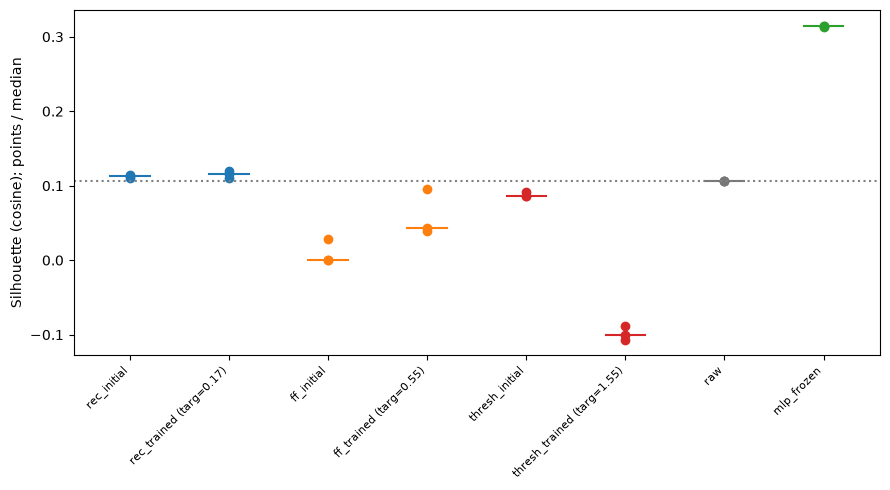

In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE)
l = tables["silhouette"][tables["silhouette"].run.isin(chosen_paths)]
for i, arm in enumerate(arms):
    values = l.loc[l.arm == arm, "silhouette"].dropna().to_numpy()
    ax.scatter(np.full(len(values), i), values, color=arm_color(arm))
    if len(values):
        ax.plot([i-.2, i+.2], [np.median(values)]*2, color=arm_color(arm))
    else:
        ax.text(i, 0, "undefined", rotation=90, ha="center", fontsize=8)
raw = l.loc[l.arm == "raw", "silhouette"].dropna()
if len(raw):
    ax.axhline(raw.median(), color="gray", linestyle=":", label="raw median")
ax.set_xticks(range(len(arms)), arm_labels, rotation=45, ha="right", fontsize=8)
ax.set(ylabel=f"Silhouette ({l.metric.iloc[0]}); points / median")
figures["G6_silhouette"] = fig

figures['G6_silhouette'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [12]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'silhouette_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G6_silhouette'], ['silhouette', 'silhouette_statistics'])

## 4. Saved endpoint checks (RF-08)

Recompute entropy and silhouette from the original saved features, using the recorded
definitions. This checks every run and both entropy axes, independently of notebook 03.
No encoder or classifier is run. These shared scientific calculations can be slower
than drawing; rerun the silhouette drawing cell alone for presentation edits.
`equal` compares with the saved metric; undefined values are explicitly recorded.

In [13]:
# Check all runs against their saved feature sources, irrespective of display targets.
anchor_metrics, _ = activity_tables(runs)
tables["endpoint_anchors"] = endpoint_anchors(runs, anchor_metrics)
display(tables["endpoint_anchors"].groupby(["equal", "undefined"], dropna=False).size().rename("checks").reset_index())
# Matching NaNs pass equality checks while remaining explicitly marked undefined.
if not tables["endpoint_anchors"].equal.all():
    raise ValueError("Saved endpoint metrics disagree with their feature sources")

,equal,undefined,checks
0,True,False,1248


In [14]:
for name in ['endpoint_anchors']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

endpoint_anchors: 1248 rows (preview below; export keeps every row)


,run,arm,model_code,targ,eta,seed_index,metric,saved,recomputed,equal,undefined
0,[local path],ff_trained,ff,0.17,0.0003,0,population.H,3.261786,3.261786,True,False
1,[local path],ff_trained,ff,0.17,0.0003,0,population.Hhat,0.472251,0.472251,True,False
2,[local path],ff_trained,ff,0.17,0.0003,0,population.S,0.527749,0.527749,True,False
3,[local path],ff_trained,ff,0.17,0.0003,0,population.S_prime,0.360766,0.360766,True,False
4,[local path],ff_trained,ff,0.17,0.0003,0,population.zero_bin_frac,0.316406,0.316406,True,False
5,[local path],ff_trained,ff,0.17,0.0003,0,population.dropped_mass,0.000000,0.000000,True,False
6,[local path],ff_trained,ff,0.17,0.0003,0,lifetime.H,1.059622,1.059622,True,False
7,[local path],ff_trained,ff,0.17,0.0003,0,lifetime.Hhat,0.179387,0.179387,True,False
8,[local path],ff_trained,ff,0.17,0.0003,0,lifetime.S,0.820613,0.820613,True,False
9,[local path],ff_trained,ff,0.17,0.0003,0,lifetime.S_prime,0.820613,0.820613,True,False


### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [15]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'endpoint_checks_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, [], ['endpoint_anchors'])

## 5. Saved UMAP coordinates (SP-02 / SP-03 / SP-06)

`RUN_UMAP` defaults to False. Enable it only to fit UMAP and save a new
coordinate snapshot. Choose an unused `ADDITIONAL_PATH` and save the
notebook before computing; then return the switch to False. Reusing an
existing path for computation is rejected. Use a new path for changed
inputs, targets, or UMAP settings.

With the switch off, the chapter loads a completed snapshot whose hashes,
inputs, and targets match the current session, without fitting UMAP.
If `ADDITIONAL_PATH` is absent, it reports that and leaves additional tables
and figures empty. Loaded coordinates retain their recorded fit settings;
editing `UMAP_PARAMS` does not change an existing snapshot.

Fit each run independently with the declared `UMAP_PARAMS` and named UMAP seed stream. Use every sample in its recorded analysis split. References are the three initial models, raw, and frozen MLP at the lowest seed; trained panels include all selected models and seeds. Coordinates, labels, split row indices, random states, effective settings and source hashes are saved.

**Qualitative reference only:** distances across independent fits are not comparable. Use the original-feature silhouette table for its separate numeric measure.

In [16]:
from importlib.metadata import version
from experiment_settings import UMAP_PARAMS
from hnn2.umap_embed import embed
from hnn2.rng import stream

if RUN_UMAP:
    if ADDITIONAL_PATH.exists():
        raise FileExistsError("Choose a new ADDITIONAL_PATH before computing")
    # Use one common seed for references and keep every selected trained seed.
    reference_seed = int(chosen.seed_index.min())
    coordinates = []
    for path, (c, a, _) in selected.items():
        identity = _identity(path, c)
        trained = c["representation"] == "sparse_trained"
        if not trained and identity["seed_index"] != reference_seed:
            continue
        split = c["analysis"]["split"]
        features = a["features"][f"h_{split}"]
        labels = a["features"][f"y_{split}"]
        sample_index = a["features"][f"sample_index_{split}"]
        random_state = int(stream(identity["seed_index"], "umap").integers(0, 2**31))
        # Fit each run independently; coordinates have no shared distance scale across runs.
        xy = embed(features, UMAP_PARAMS, random_state=random_state)
        frame = pd.DataFrame({"x": xy[:, 0], "y": xy[:, 1], "label": labels,
            "sample_index": sample_index, "split": split, "random_state": random_state,
            "panel_group": "trained" if trained else "reference"}).assign(**identity)
        coordinates.append(frame)
        print("Embedded", identity["arm"], identity["seed_index"], len(frame))
    extra_tables = {"umap_coordinates": pd.concat(coordinates, ignore_index=True)}
    details = {"ids": ["SP-02", "SP-03", "SP-06"], "training": False,
        "umap_params": UMAP_PARAMS.to_json(), "umap_learn_version": version("umap-learn"),
        "reference_seed": reference_seed, "random_state": "stream(seed_index, 'umap').integers(0, 2**31)",
        "fit": "independent fit per run; all samples in the saved analysis split",
        "sample_index": "row within the saved dataset split, not original MNIST identity",
        "interpretation": "Qualitative reference only; distances across independent fits are not comparable"}
    # Persist coordinates and fit provenance for later drawing without fitting again.
    save_figure_tables(ADDITIONAL_PATH, extra_tables, runs, targets=targets,
        selection_directory=selection_directory, notebook_path=NOTEBOOK_PATH,
        coverage=coverage, analysis_targets=effective, details=details)

    # Keep effective settings and the shared settings source with this snapshot.
    (ADDITIONAL_PATH / "figure_settings.py").write_bytes((ROOT / "notebooks/figure_settings.py").read_bytes())
    (ADDITIONAL_PATH / "notebook_settings.json").write_text(json.dumps({
        "results": str(RESULTS.resolve()), "effective_targets": targets,
        "additional_path": str(ADDITIONAL_PATH.resolve()), "details": details}, indent=2), encoding="utf-8")
    numeric_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                      for p in ADDITIONAL_PATH.iterdir() if p.is_file()}
    (ADDITIONAL_PATH / "numeric_sha256.json").write_text(json.dumps(numeric_hashes, indent=2), encoding="utf-8")
    print("Saved additional numeric analysis:", ADDITIONAL_PATH)

In [17]:
# Read only completed, unchanged numeric snapshots matching the current inputs.
extra_tables, extra_figures = {}, {}
extra_metadata = None
if ADDITIONAL_PATH.exists():
    if not (ADDITIONAL_PATH / "COMPLETE").is_file():
        raise ValueError("Additional analysis is incomplete; use a new path")
    numeric_hashes = json.loads((ADDITIONAL_PATH / "numeric_sha256.json").read_text(encoding="utf-8"))
    for name, digest in numeric_hashes.items():
        if hashlib.sha256((ADDITIONAL_PATH / name).read_bytes()).hexdigest() != digest:
            raise ValueError(f"Additional numeric source changed: {name}")
    extra_metadata = json.loads((ADDITIONAL_PATH / "conditions.json").read_text(encoding="utf-8"))
    current_sources = [{"path": path, "sha256": c["loaded_source_sha256"]}
                       for path, (c, _, _) in runs.items()]
    if extra_metadata["source"] != current_sources or extra_metadata["display_targets"] != targets:
        raise ValueError("Additional analysis belongs to different inputs or targets")
    for key in ("selection", "population_sources"):
        if extra_metadata[key] != coverage.attrs["figure_sources"][key]:
            raise ValueError(f"Additional analysis has different {key}")
    extra_tables = {p.stem: pd.read_csv(p, float_precision="round_trip")
                    for p in ADDITIONAL_PATH.glob("*.csv")}
    print("Loaded additional analysis:", ADDITIONAL_PATH)
else:
    print("Additional analysis is absent. Enable its computation switch explicitly to create it.")

Loaded additional analysis: outputs\synthetic_long_v1\analysis\notebook_figures_v2\additional\geometry_v1


In [18]:
if extra_tables:
    display(extra_tables["umap_coordinates"].groupby(["panel_group", "arm", "seed_index"]).size().rename("samples"))
    display(extra_tables["umap_coordinates"].head(12))
    display(extra_metadata["additional_analysis"])

panel_group  arm             seed_index
reference    ff_initial      0             1024
             mlp_frozen      0             1024
             raw             0             1024
             rec_initial     0             1024
             thresh_initial  0             1024
trained      ff_trained      0             1024
                             1             1024
                             2             1024
             rec_trained     0             1024
                             1             1024
                             2             1024
             thresh_trained  0             1024
                             1             1024
                             2             1024
Name: samples, dtype: int64

,x,y,label,sample_index,split,random_state,panel_group,run,arm,model_code,targ,eta,seed_index
0,3.265789,2.833792,5,0,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
1,10.678461,0.225179,4,1,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
2,4.314391,3.609133,3,2,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
3,18.668274,3.854061,6,3,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
4,8.956271,-2.193071,9,4,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
5,3.411833,10.162055,0,5,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
6,-1.599950,3.688988,1,6,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
7,4.753744,13.241708,0,7,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
8,8.697614,5.216867,7,8,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0
9,3.301155,1.491146,8,9,test,721690110,trained,[local path],ff_trained,ff,0.55,0.0001,0


{'ids': ['SP-02', 'SP-03', 'SP-06'],
 'training': False,
 'umap_params': {'n_neighbors': 3,
  'min_dist': 0.1,
  'metric': 'cosine',
  'n_components': 2},
 'umap_learn_version': '0.5.12',
 'reference_seed': 0,
 'random_state': "stream(seed_index, 'umap').integers(0, 2**31)",
 'fit': 'independent fit per run; all samples in the saved analysis split',
 'sample_index': 'row within the saved dataset split, not original MNIST identity',
 'interpretation': 'Qualitative reference only; distances across independent fits are not comparable'}

### Display settings and drawing

For style changes, rerun these two cells only. Numeric snapshots remain unchanged.

In [19]:
UMAP_PANEL_SIZE = (4.5, 4)
UMAP_CMAP = "tab10"
UMAP_POINT_SIZE = 5

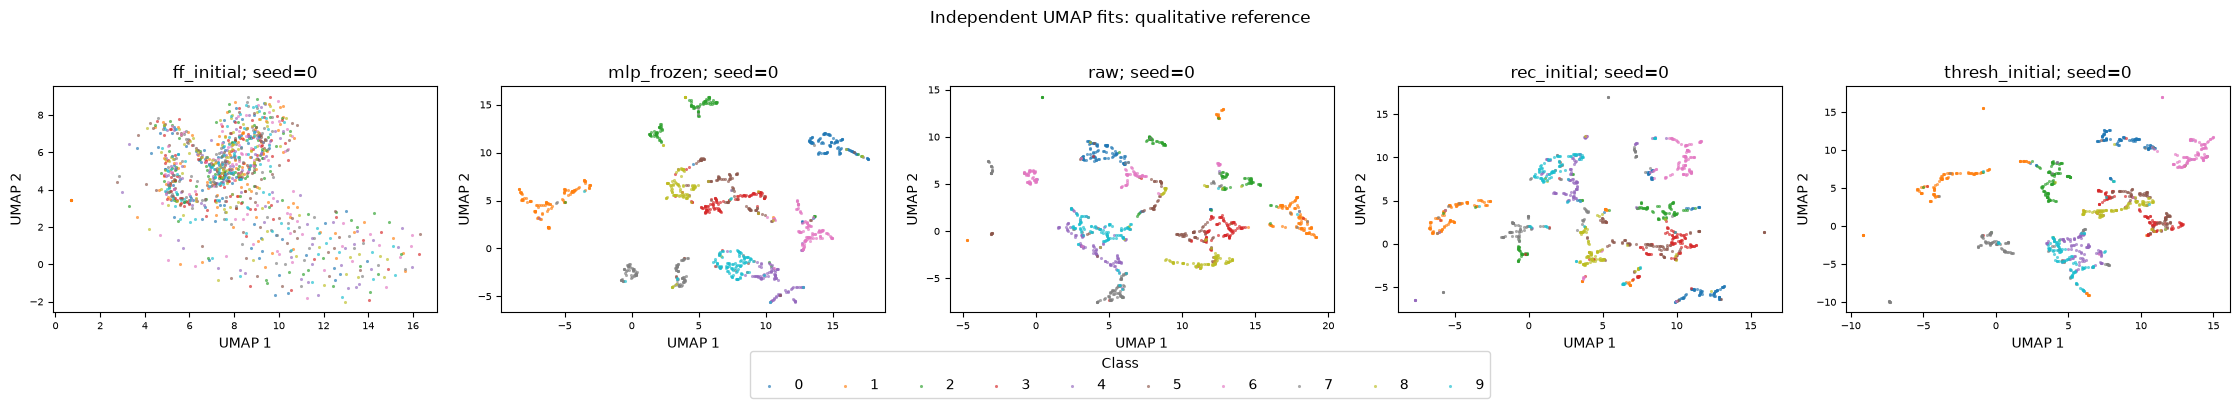

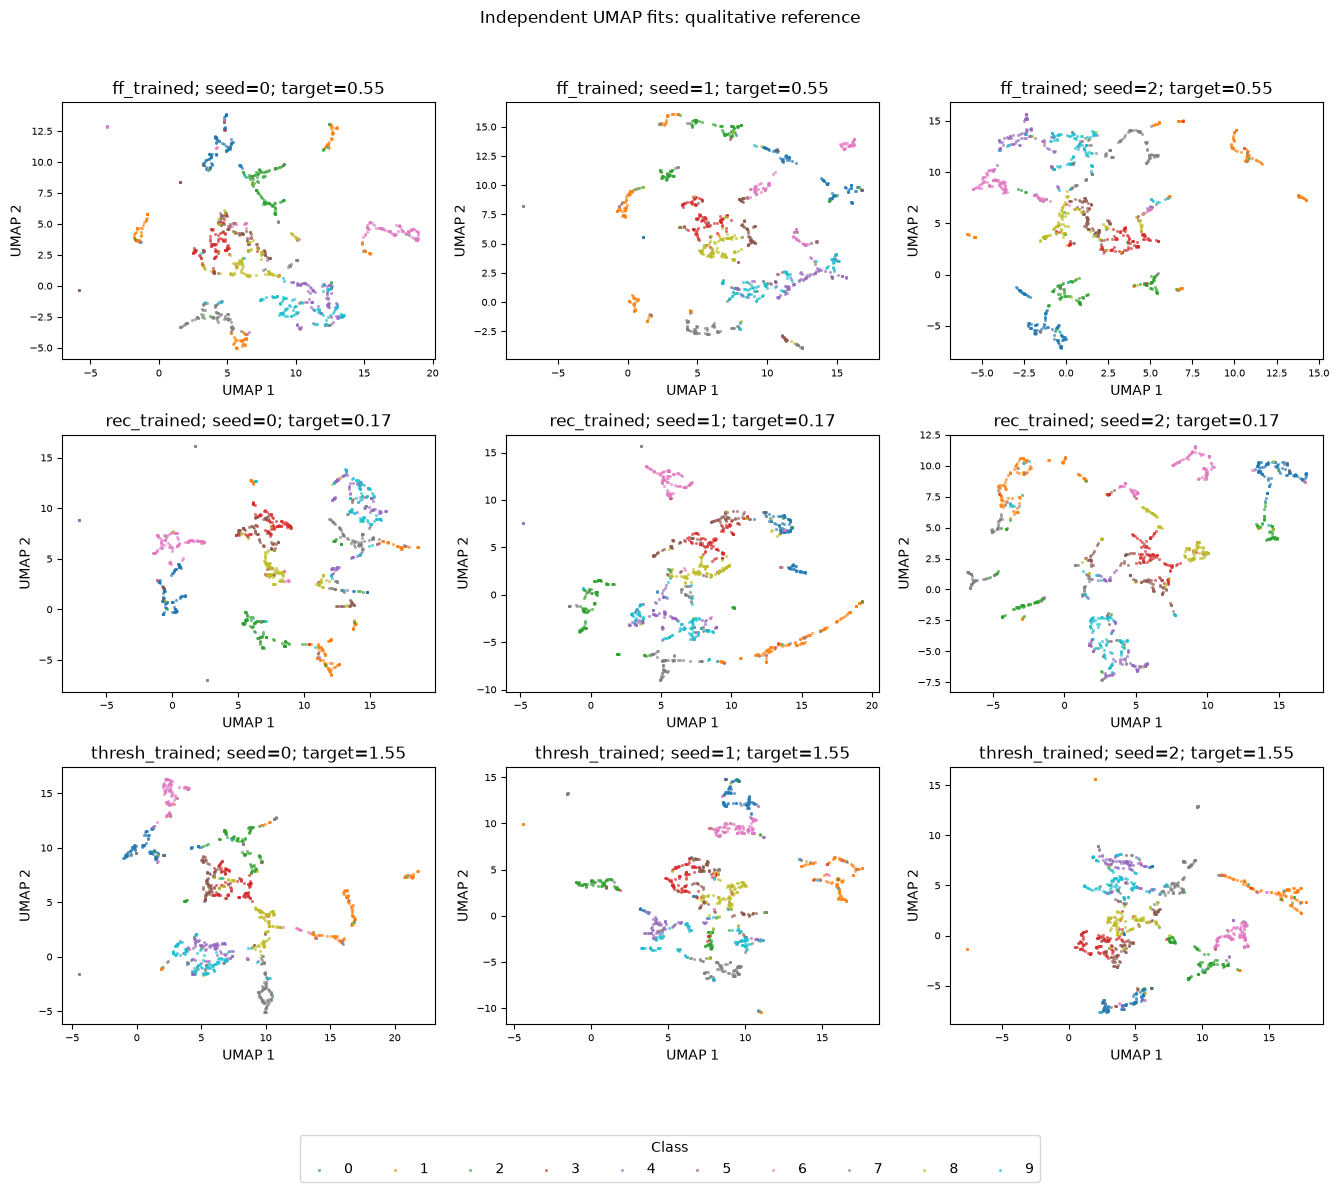

In [20]:
extra_figures = {}
if extra_tables:
    coordinates = extra_tables["umap_coordinates"]
    # Use the same class-to-color mapping across every independent fit.
    classes = sorted(coordinates.label.unique())
    cmap = plt.get_cmap(UMAP_CMAP, len(classes))
    for group in ("reference", "trained"):
        subset = coordinates[coordinates.panel_group == group]
        run_groups = list(subset.groupby("run", sort=False))
        columns = 5 if group == "reference" else len(models)
        rows = int(np.ceil(len(run_groups)/columns))
        fig, axes = plt.subplots(rows, columns, figsize=(UMAP_PANEL_SIZE[0]*columns, UMAP_PANEL_SIZE[1]*rows), squeeze=False)
        for ax, (_, frame) in zip(axes.ravel(), run_groups):
            for i, label in enumerate(classes):
                points = frame[frame.label == label]
                ax.scatter(points.x, points.y, s=UMAP_POINT_SIZE, color=cmap(i), alpha=.65, label=str(label), linewidths=0)
            first = frame.iloc[0]
            target = "" if pd.isna(first.targ) else f"; target={first.targ:g}"
            ax.set(title=f"{first.arm}; seed={int(first.seed_index)}{target}", xlabel="UMAP 1", ylabel="UMAP 2")
            ax.tick_params(labelsize=7)
        for ax in axes.ravel()[len(run_groups):]: ax.set_visible(False)
        handles, labels = axes.ravel()[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=len(classes), title="Class")
        fig.suptitle("Independent UMAP fits: qualitative reference", fontsize=12)
        fig.tight_layout(rect=(0, .09, 1, .96))
        extra_figures[f"G6_umap_{group}"] = fig
        if SHOW_FIGURES: display(fig)
        plt.close(fig)

### Save additional figures

After loading a numeric snapshot and drawing its figures, set
`SAVE_ADDITIONAL_FIGURES=True` and choose a new `ADDITIONAL_EXPORT_NAME`.
PNG/PDF switches control the image formats. The images record the path
and hashes of the numbers in `ADDITIONAL_PATH`; those numbers are not copied.
The final export also includes these figures when they have been prepared.

In [21]:
def export_additional_figures(destination):
    """Export prepared figures with a hash link to the saved additional numbers."""
    if not extra_figures:
        print("No additional figures prepared")
        return
    for name, digest in numeric_hashes.items():
        if hashlib.sha256((ADDITIONAL_PATH / name).read_bytes()).hexdigest() != digest:
            raise ValueError(f"Additional numeric source changed: {name}")
    save_basic_figures(extra_figures, destination, png=SAVE_PNG, pdf=SAVE_PDF,
                       numeric_source=ADDITIONAL_PATH)

SAVE_ADDITIONAL_FIGURES = False
ADDITIONAL_EXPORT_NAME = "additional_v1"  # New name for every presentation change.
if SAVE_ADDITIONAL_FIGURES:
    if Path(ADDITIONAL_EXPORT_NAME).name != ADDITIONAL_EXPORT_NAME or ADDITIONAL_EXPORT_NAME in ("", ".", ".."):
        raise ValueError("Use a simple new export name")
    export_additional_figures(OUTPUT / NOTEBOOK_OWNER / ADDITIONAL_EXPORT_NAME / "figures")

## Export all figures and tables in this notebook

Run all main chapters first. Set `SAVE_NUMBERS=True` in Settings and choose
a new `EXPORT_NAME`. This saves the CSVs listed in `OWNED_TABLES`, prepared
main-chapter figures in the enabled formats, input/HP/population hashes,
effective targets, a notebook copy, and export settings.

Chapter exports must use different names. Save the notebook file before
exporting; after style changes, rerun the drawing cells and use a new name.

If the additional figures have been prepared, this export also saves them
under `additional_figures/` in the enabled formats. Their numeric tables
remain in `ADDITIONAL_PATH`; the image export records that path and its hashes.
Loading and redrawing a completed snapshot requires no new computation.

In [22]:
print("Tables owned by this notebook:", OWNED_TABLES)
print("Figures prepared:", list(figures))
if SAVE_NUMBERS:
    export_section(EXPORT_NAME, list(figures), OWNED_TABLES)
else:
    print("Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.")
if SAVE_NUMBERS and extra_figures:
    export_additional_figures(OUTPUT / NOTEBOOK_OWNER / EXPORT_NAME / "additional_figures")

Tables owned by this notebook: ['silhouette', 'silhouette_statistics', 'endpoint_anchors']
Figures prepared: ['G6_silhouette']
Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.
